<a href="https://colab.research.google.com/github/jmcardenas8/Notebooks-Pregrado-Astronomia/blob/main/Mecanica-de-medios-continuos/MCON_Tarea5_ModelosCosmol%C3%B3gicos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<p>
<h1><b><center></center></b></h1>
<center><img src="https://drive.google.com/uc?id=1UJc1ci41G6ahJ7ProKvunUOIBcTXZ6ZG" align="center" width="550"></center>
</p>
<h1><b><center>Mecánica de Medios Continuos</center></b></h1>
<h2><b><center>Prof. Jorge I. Zuluaga</center></b></h1>
<h2><b><center>Tarea 5</center></b><h2>
<h3><b><center>Modelos Cosmológicos</center></b><h3>
<h5><center><b>Asignada</b>: 7 de Mayo de 2024</center><h5>
<h5><center><b>Entrega</b>: 21 de Mayo de 2024</center><h5>
</p>

<hr/>
<b>Nombre</b>: Juan Manuel Cardenas
<br/>
<b>Cédula</b>: 1002587562
<br/>
<b>Última actualización</b>: 12/7/24
<hr/>
<br>
Importando Librerias:

In [ ]:
!pip install -q celluloid # animaciones

In [ ]:
import numpy as np
import scipy.constants as cts
import matplotlib.pyplot as plt
import astropy.constants as astrocts
import astropy.units as u

from cycler import cycler # ciclo de colores en grafica
from celluloid import Camera # animacion 2d
from IPython.display import HTML # visualizar animacion 2d
from matplotlib.colors import Normalize # escala de colores
from numpy import concatenate as concat # concatenar arreglos
from astropy.cosmology import WMAP9, Planck18 # paquetes de cosmologia
from scipy.integrate import solve_ivp,quad as integral # solucion EDs

plt.style.use('seaborn-v0_8-dark-palette')

### **Objetivo**:

* El objetivo de esta tarea es resolver las ecuaciones de **Firedmann-Lemaitre** para describir la expansión del universo bajo distintas condiciones de contenido de masa-energía y otros observables cosmológicos.

<br><br>

___

## **I. Cálculos Numéricos:**

___

<br>

### **1. Unidades Canonicas Cosmológicas**
1. Vamos a introducir unas unidades convenientes para tratar numéricamente con problemas cosmológicos. En estas unidades $G=1$, $c=1$ y $H_0=1$. Llamaremos a estas las *unidades canónicas de la cosmología*. Determine el valor de las unidades de tiempo, longitud, masa y densidad.  



#### **Calculo de valores**:

* **Unidad Canonica de Tiempo**: Fijo el parametro de Hubble-laimetre en la actualidad $H_0$ con unidades [1/s] basta entonces con invertirlo para obtener la unidad de tiempo:
  $$ U_t = 1/H_0$$

* **Unidad Canonica de Longitud**: Como se fijo el tiempo (con $H_0$ [1/s]) y ademas tambien se fijó la velocidad de la luz $c$ [m/s], se obtiene la unidad de longitud de con su producto:
  $$ U_l = c/H_0 = c \ U_t $$

* **Unidad Canonica de Masa**: Con las dos unidades canonicas anteriores y con la constante gravitacional fija, se puede despejar asi la unidad de masa:

  $$ G = U_l^3/(U_t^2 U_m) $$
  $$ U_m = U_l^3/(U_t^2 G) $$

Con estas unidades basicas se pueden deducir otras unidades como la de velocidad y densidad. Por otra parte, los datos como la constante de Hubble actual o la edad del universo fueron tomadas del paquete de `astropy`, particularmente de los subpaquetes cosmologicos basados en las misiones `WMAP` y `Planck`.





In [ ]:
# constantes importantes
pi = np.pi
G  = astrocts.G.value     # [m^3/s^2 kg]
c  = astrocts.c.value     # [m/s]
Ho = WMAP9.H(0)           # [km/s/Mpc]
Ho_s = Ho.to_value('1/s') # [1/s]
pc = astrocts.pc.value    # [m]

# Unidades Canonicas
U_t = 1/Ho_s              # [s]
U_l = c/Ho_s              # [m]
U_m = U_l**3/(G*U_t**2)   # [kg]

# Unidades derivadas
U_v = c                           # [m/s]
U_ρ = U_m/U_l**3                  # [kg/m^3]
Ut_Gy = (U_t*u.s).to_value('Gyr') # [Gyr]

# otros datos
age_w9 = WMAP9.age(0).value       # [Gyr]
age_p18 = Planck18.age(0).value   # [Gyr]

Imprimiendo valores de unidades canonicas:

In [ ]:
print(f"Unidades Canonicas Cosmologicas:\n")
print(f"- Tiempo: {(U_t*u.s).to('Myr'):.2f}")
print(f"- Masa: {U_m*u.kg:.2e} = {(U_m*u.kg).to('Msun'):.2e}")
print(f"- Longitud: {(U_l*u.m).to('Mpc'):.2f} = {(U_l*u.m).to('Mlyr'):.2f}")
print(f"- Densidad: {U_ρ} kg/m^3 = {U_ρ*(u.kg/(u.m**3)).to('Msun/(Mpc^3)'):.2e} solMass/Mpc^3")

Unidades Canonicas Cosmologicas:

- Tiempo: 14105.49 Myr
- Masa: 1.80e+53 kg = 9.04e+22 solMass
- Longitud: 4324.76 Mpc = 14105.49 Mlyr
- Densidad: 7.561540698104593e-26 kg/m^3 = 1.12e+12 solMass/Mpc^3


#### **Relacion de Unidades Canonicas y la Naturaleza**<br>

**Unidad de longitud y Radio de Hubble**

* Por definicion la unidad canonica de longitud está basada en la tasa de expansión actual y corresponde con el **Radio de Hubble** actual ($R_H = c/H_o = U_l$), radio despues del cual, el espacio se aleja a una velocidad mayor que $c$ respecto a un observador en el centro de la esfera. Esto implicaria que el observador nunca podria ver la luz emitida por objetos fuera de este radio, siempre que $H$ fuera constante.
$$ \vec{V} = H(t) \vec{X}$$
No obstante, en un universo con parametro de Hubble variable en el tiempo; Si la expancion del universo desacelera ($H$ disminuye), entonces $R_H$ aumentaria, lo que haria posible ver objetos que hubieran estado fuera de la esfera definida por $R_H$ (volumen de Hubble). Mientras que si la expansion ascelera ($H$ aumenta) y $R_H$ disminuiria, por lo que objetos que esten dentro de la esfera con el tiempo podrian terminar saliendo de la misma y dejar de ser visibles para el observador.
<br><br>

**Uniad de Masa y Masa del univeraso observable**

* El universo observable contiene un numero de galaxias aproximado del orden $10^{12}$, y en promedio una galaxia tiene del orden de $10^{11}$ masas solares; lo que resulta en un estimado del orden de magnitud de la masa total dentro del universo observable de $10^{23}$ masas solares $ = 10^{53}$ kg. Aclarando que este valor corresponde al universo observable, y no al volumen de Hubble, que como se muestra mas adelante, no son iguales.
<br><br>

**Unidad de tiempo y Edad del Universo**

* Su definiicion depende unicamente del parametro de Hubble actual $H_0 = 70$ km/s/mpc, que quiere decir que por cada megaparsec el espacio se expande a $70$ km/s. $H_0$ tambien se puede ver como la frecuencia asociada a la velocidad de expancion del universo desde que este tuvo inicio, de modo que invirtiendola se encuentra el tiempo que lleva el universo expandiendose, este tiempo se basa en el supuesto que $H_0$ no hubiera cambiado en el tiempo, cosa que no ocurre, lo que explica la diferencia que existe entre esta unidad y la edad real del universo.  <br>

<p align="center">
<img src= https://i.postimg.cc/63LYc7cm/main-qimg-8f44f3a5bee4f89d4767ecbfe58151bd-lq.jpg width="450">
</p>

<center>
  Figura 1. Estructura a gran escala del universo observable y el volumen de Hubble.
</center>


En general, los valores de estas unidades dan una nocion de las dimensiones del sistema a estudiar y en particular para este caso son una buena primera aproximacion a las propiedades del universo a gran escala, como la edad, masa, tamaño y densidad.

Estas unidades difieren de los valores medidos por observaciones debido particularidades como: la variacion de $H(t)$ y de la expancion del universo en el tiempo. Ademas del hecho de que las observaciones tienen en cuenta el universo observable y no solamente el volumen de Hubble, del cual se basan las unidades canonicas cosmologicas; Por estas razones los valores no coinciden exactamente, pero si su orden de magnitud.
<br>

* Volumen de Hubble. Recuperado de: https://es.wikipedia.org/wiki/Volumen_de_Hubble
* Numero de Galaxias en el universo observable. Recuperado de: https://en.wikipedia.org/wiki/Galaxy

* Imagen universo observable y radio de Hubble. Recuperado de: https://bigthink.com/starts-with-a-bang/universes-galaxies-unreachable/

<br>

**DIFERENCIA: Radio de Hubble $R_H$ y Universo Observable $R_{\text{obs}}$**

Debido a la edad del universo y la expansion acelerada se tiene que $R_{\text{obs}} > R_H$. La distancia comóvil al Big Bang puede dar una idea del tamaño del universo observable, y con el paquete `Planck18` se puede obtener la distancia comovil al big bang tomando un redshift $z$ tendiendo a infinito `np.inf`




In [ ]:
r_obs = Planck18.comoving_distance(np.inf)
r_hubble = (U_l*u.m).to('Mpc')

print("Radios:")
print(f"- Hubble: {(U_l*u.m).to('Mpc'):.1f} = {(U_l*u.m).to('Mlyr'):.1f}")
print(f"- Universo Observable: {r_obs:.1f} = {r_obs.to('Mlyr'):.1f}")

Radios:
- Hubble: 4324.8 Mpc = 14105.5 Mlyr
- Universo Observable: 14165.2 Mpc = 46200.6 Mlyr


**DIFERENCA: Masa de Hubble y del Universo Observable**

Usando $R_{\text{obs}}$ en un volumen esferico, y usando la densidad total del universo a partir del parametro de densidad total $Ω$ y la densidad critica del universo actual $ρ_{c0}$ del paquete `Planck18`, se puede obtener la masa:

In [ ]:
vol_obs = 4*pi*r_obs**3/3          # volumen esferico
Ω_m = Planck18.Om0                 # omega total actual
ρ_c = Planck18.critical_density(0) # densidad critica actual
ρ_obs = Ω_m*ρ_c.to('kg/Mpc^3')     # densidad univers obs

mass_obs = ρ_obs*vol_obs           # masa univers obs

print(f"- Masa del Universo Observable: {mass_obs:.1e}")
print(f"- Masa del volumen de hubble: {U_m*u.kg:.1e}")

- Masa del Universo Observable: 9.3e+53 kg
- Masa del volumen de hubble: 1.8e+53 kg


<br><br>

___

### **2. Las Ecuaciones del Universo Fluido**

2. Escriba las ecuaciones diferenciales para $H(t)$ y $\rho(t)$ obtenidas a partir de la conservación de la masa y la segunda ley de Newton (ecuación de Cauchy)
<br><br>
$$  
\left\{
\begin{aligned}
    \dot{\rho} & = -3 \rho H(t) && \text{Ec. continuidad} \\
    \dot{H} + H^2 & = -\frac{4 \pi}{3} G \rho(t) && \text{Ec. Cauchy}
\end{aligned}
\right.
$$
<br><br>
En unidades canónicas. Asumiendo como valores actuales $\rho(t_0)=\rho_0=3 * 10^{-27}$ kg/m$^3$ y $H(t_0) = H_0 = 70$ km/s/Mpc, integre numéricamente las ecuaciones hacia el futuro usando $t_0=0$. Recuerde que todo debe hacerlo en unidades canónicas.
<br>

**Funcion del sistema a integrar:**

* Debido a que se fijó la constante de gravitacion $G$ en 1 para las unidades canonicas, entonces como convencion al escribir las ecuaciones en el codigo en todo el notebook no se escribió explicitamente el simbolo $G$ en las ecuaciones por facilidad de lectura, no obstante se debe tener presente que todas las ecuaciones estan escritas en unidades canonicas y cuales son sus valores.
Con esto en cuenta, el sistema anterior (las ecuaciones de continuidad y de Cauchy) se definió con una funcion para ser entregada al integrador `solve_ivp`





In [ ]:
def sistem_cosmo(t,y):
  """
  sistema de ecuaciones de mov del universo fluido
  (ec continuidad y cauchy) ajustado para solve_ivp

  input:  t: tiempos (array)
          y: condiciones iniciales (list)

  output: dH_dt: cambio del parametro de hubble
          dρ_dt: cambio de la densidad
  """
  ρ, H = y

  # sistema
  dρ_dt = -3*ρ*H
  dH_dt = -H**2 - 4*pi*ρ/3

  return [dρ_dt, dH_dt]

**Solucion Hacia el Futuro**<br>

Definiendo un arreglo de tiempos (del presente al futuro) en unidades canonicas, junto a las condiciones iniciales del presente para el parametro de Hubble y la densidad, y la funcion previa del sistema de ecuaciones, se puede obtener la solucion de $H(t)$ y $ρ(t)$ hacia el futuro mediante `solve_ivp`.

In [ ]:
# tiempo futuro
to = 0    # inicial
tf = 10   # final
t_f = np.linspace(to, tf, 500)

# condiciones iniciales del sistema
Hto = 70/Ho.value # [1/U_t]
ρo = (3e-27)/U_ρ  # [U_ρ]
yo = [ρo, Hto]    # ICS

# solucion futuro
sol_f = solve_ivp(sistem_cosmo, [to,tf], yo, t_eval=t_f)
ρ, H = sol_f.y
t_f = sol_f.t

**Grafica de la evolucion de $H$ y $ρ$ en el Futuro**

Tomando las soluciones en unidades canonicas entregadas de la integracion por solve_ivp y pasandolas a unidades fisicas (multiplicando por su respectivo valor de la unidad canonica deseada) para su graficacion:

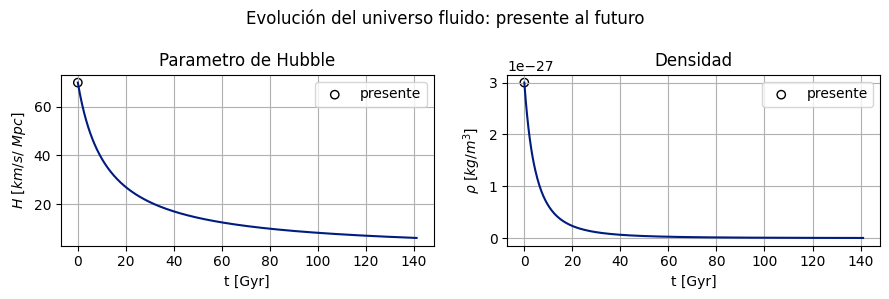

In [ ]:
fig, ax = plt.subplots(1,2,figsize=(9,3))
plt.suptitle('Evolución del universo fluido: presente al futuro')

ax[0].set_title('Parametro de Hubble')
ax[0].plot( t_f * Ut_Gy, H * Ho)
ax[0].set_ylabel('$H$ $[km/s/ \ Mpc]$')
ax[0].set_xlabel('t [Gyr]')
ax[0].scatter(0,H[0]*Ho,label='presente',edgecolor='k',facecolor='none')
ax[0].legend()
ax[0].grid()

ax[1].set_title('Densidad')
ax[1].plot( t_f * Ut_Gy, ρ * U_ρ)
ax[1].set_ylabel('$ρ$ $[kg/m^3$]')
ax[1].set_xlabel('t [Gyr]')
ax[1].scatter(0,ρ[0]*U_ρ,label='presente',edgecolor='k',facecolor='none')
ax[1].legend()
ax[1].grid()
plt.tight_layout()
plt.show()

<br>

___

### **3. La Edad del Universo** (segun sistema universo fluido)

3. Integre ahora las ecuaciones hacia el pasado. Tenga en cuenta que por la naturaleza de la expansión, en algún instante la densidad se hará infinita. Determine por tanteo el valor $\tau$ (negativo, porque es en el pasado) para el cuál la integral produce valores muy grandes, pero no infinitos de la densidad (asíntota). Este valor, $\tau$ es la edad del universo predicha por el modelo.
<br><br>


**Solucion Hacia el Pasado:** <br>

Ahora tomando un arreglo de tiempos desde el presente hacia el pasado (tiempo en unidades canonicas negativas)


El sistema 1 falla y se detiene en un punto del pasado por overflow, de modo que el integrador acorta respecto al punto de overflow los datos, y para poder corresponder las dimensiones, tambien se debe cortar el arreglo de tiempos segun las soluciones.

In [ ]:
# tiempo pasado
tp = -1.2      # tiempo final
t_p = np.linspace(to, tp, 500)

# solucion pasado
sol_past = solve_ivp(sistem_cosmo, [to,tp], y0=yo, t_eval=t_p)
ρ_p, H_p = sol_past.y
t_p = sol_past.t

**Grafica de la evolucion $H$ y $ρ$ hacia el pasado**

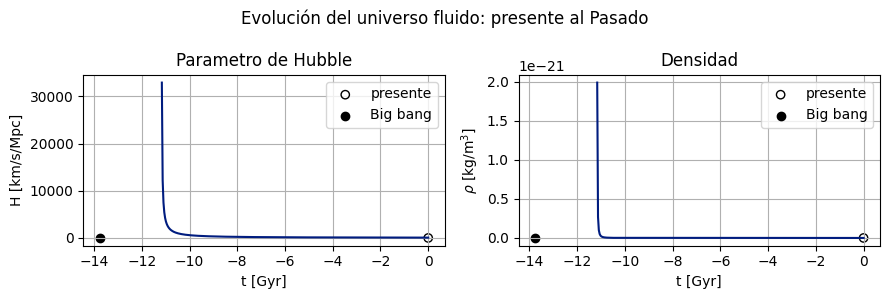


Edad del universo:

- Segun Mision WMAP9: 13.768899 Gyr
- Segun Mision Planck18: 13.786885 Gyr
- Estimada del sistema universo-fluido: 11.160011 Gyr


In [ ]:
fig, ax = plt.subplots(1,2,figsize=(9,3))
plt.suptitle('Evolución del universo fluido: presente al Pasado')

ax[0].set_title('Parametro de Hubble')
ax[0].plot( t_p * Ut_Gy, H_p * Ho )
ax[0].set_ylabel('H [km/s/Mpc]')
ax[0].set_xlabel('t [Gyr]')
ax[0].scatter(0,0,label='presente',edgecolor='k',facecolor='none')
ax[0].scatter(-age_w9,0, label='Big bang', color='k')
ax[0].legend()
ax[0].grid()

ax[1].set_title('Densidad')
ax[1].plot( t_p * Ut_Gy, ρ_p * U_ρ )
ax[1].set_ylabel('$ρ$ [kg/m$^3$]')
ax[1].set_xlabel('t [Gyr]')
ax[1].scatter(0,0,label='presente',edgecolor='k',facecolor='none')
ax[1].scatter(-age_w9,0, label='Big bang', color='k')
ax[1].legend()
ax[1].grid()
plt.tight_layout()
plt.show()

# Edades del universo
age_try = -t_p[-1]*Ut_Gy # edad estimada solucion universo-fluido
print(f'\nEdad del universo:\n')
print(f'- Segun Mision WMAP9: {age_w9:4f} Gyr')
print(f'- Segun Mision Planck18: {age_p18:4f} Gyr')
print(f'- Estimada del sistema universo-fluido: {age_try:4f} Gyr')

#### **Universos con otras densidades actuales $ρ_0$**

* ¿Qué pasa con la edad del universo para valores de $\rho_0$ mayores o menores?.

Para responder a esta pregunta en el mismo contexto del sistema del universo fluido, se tomó un arreglo con diferentes densidades actuales; siendo las elegidas $0, 0.5, 1, 10$ y $1e^6$ veces $ρ_0$, de esta manera con un ciclo se solucionó el sistema con cada una de estas condiciones iniciales distintas, se imprimió la edad asociada a cada una de las soluciones y se graficaron las curvas de $H$ y $ρ$ en funcion del tiempo de cada solucion para compararlas visualmente

Estimacion de la Edad del universo variando densidad actual:

- Con ρo = 0.0 ρo, la Edad es = 13.9415 [Gyr]
- Con ρo = 0.5 ρo, la Edad es = 12.0420 [Gyr]
- Con ρo = 1.0 ρo, la Edad es = 11.1600 [Gyr]
- Con ρo = 10.0 ρo, la Edad es = 6.9877 [Gyr]
- Con ρo = 1000000.0 ρo, la Edad es = 0.0339 [Gyr]




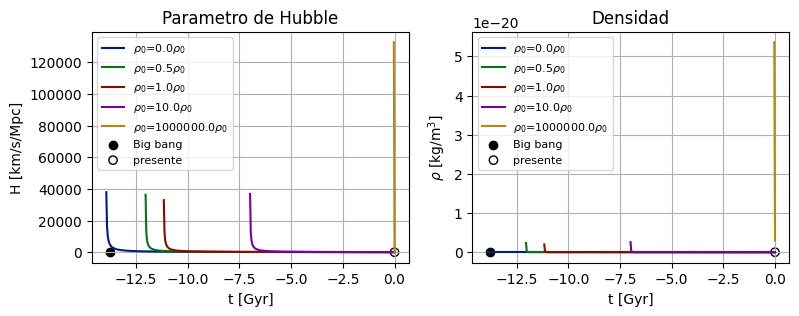

In [ ]:
# condiciones iniciales del sistema
ρs = np.array([0, 0.5, 1, 10, 1e6])*ρo # densidades actuales
t_pi = np.linspace(to, tp, 500)        # tiempo (presente al pasado)


# grafica (evolucion para cada densidad)
fig, ax = plt.subplots(1,2,figsize=(9,3))
print('Estimacion de la Edad del universo variando densidad actual:\n')


for ρi in ρs: # cada densidad

  # solucion pasado
  yoi = [ρi, Hto] # ICS
  sol = solve_ivp(sistem_cosmo, [to,tp], y0=yoi, t_eval=t_pi)
  ρ_pi, H_pi = sol.y
  tp_i = sol.t * Ut_Gy

  # grafica
  ax[0].set_title('Parametro de Hubble')
  ax[0].plot(tp_i, H_pi * Ho, label=f'$ρ_0$={ρi/ρo}$ρ_0$')
  ax[0].set_ylabel('H [km/s/Mpc]')
  ax[1].set_title('Densidad')
  ax[1].plot(tp_i, ρ_pi * U_ρ, label=f'$ρ_0$={ρi/ρo}$ρ_0$')
  ax[1].set_ylabel('$ρ$ [kg/m$^3$]')

  age_tryi = -tp_i[-1] # edad del universo asociada
  print(f'- Con ρo = {ρi/ρo} ρo, la Edad es = {age_tryi:.4f} [Gyr]')

# config de grafica
print('\n')
for i in range(2):
  ax[i].scatter(-age_w9,0, label='Big bang', color='k')
  ax[i].scatter(0,0,label='presente',edgecolor='k',facecolor='none')
  ax[i].set_xlabel('t [Gyr]')
  ax[i].legend(fontsize=8)
  ax[i].grid()
plt.show()

Note que si se aumenta mucho la densidad actual, la edad del universo tiende a cero, esto da un indicio de que al principio del universo, cuando su edad es cero, la densidad del universo tiende a infinito, el big bang.

Por otro lado hay que tener claro que esta estimacion de la edad depende mucho de las limitaciones computacionales al manejar los numeros extremadamente grandes que se encuentran cerca del big bang. El integrador solve_ivp es capaz de detectar cuando se da un overflow en estos eventos y detiene la integracion en un valor previo; es por esta razon que la estimacion de la edad del universo con la densidad actual no llega a los teoricos $14$ Gyr, sino cerca de los $11$ Gyr. Con el agregado de que sistema del universo fluido no tiene en cuenta la influencia de la energia oscura lo cual tambien afecta el valor de la edad estimada.
<br><br>


#### **VISUALIZACION: Ley de Hubble-Lemaitre**

Adicionalmente, para visualizar el comportamiento de la velocidad del espacio en las componentes  $XY$ en funcion del tiempo, segun la ley de ley de Hubble-Lemaitre:
$$ \vec{V} = H(t) \vec{X}$$

Se creó una rutina para la velocidad $2D$ que toma como argumento el arreglo de la evolucion del parametro de hubble $H(t)$ y las posiciones del espacio $(x,y)$ con un meshgrid segun un observador situado en un origen de un sistema de referencia arbitrario.

La idea es crear una animacion del campo vectorial de velocidades del espacio en funcion del tiempo, mostrando densidad y tiempo asociado a cada instante, primero para un universo abierto y mas adelante en el notebook para un universo cerrado. La animacion del universo abierto se realizó tomando la solucion previa del sistema de ecuaciones del universo fluido. Mientras la animacion del universo cerrado se hará mas adelante en el notebook, empleando el sistema de Friedmann-Laimetre, donde se tomará una de las soluciones en las que la densidad de materia comun domina, y el universo colapsa.

In [ ]:
def velocity(H, rx,ry):
  """
  velocidad segun ley hubble-lemaitre
  input:
    H: parametro de hubble H(t) (array)
    rx,ry: posiciones del espacio

  output:
    vx, vy: velocidad del espacio
  """
  vx = H*rx
  vy = H*ry
  return vx, vy

#### **Graficacion de la velocidad en un universo abierto**

Se intentó que la densidad tambien se mostrara asociada a un color de fondo en la animacion; siendo el color rojo cuando la densidad es mas alta, y el color azul cuando es mas baja, usando funciones como `pcolormesh`, `get_cmap` y `Normalize`.

Teniendo en cuenta la solucion al sistema de ecuaciones del universo fluido, con la solucion dese el pasado al presente, usando el mapa vectorial de
`quiver` para las velocidades (las normas de los vectores debido al gran tamaño de los datos estan normalizadas a una escala menor para su visualizacion).



In [ ]:
# campos
H_open = concat((H_p[::-1], H))[:50]
ρ_open = concat((ρ_p[::-1], ρ))[:50]
t_open = concat((t_p[::-1], t_f))[:50]

# campo velocidad
xx = np.linspace(-4,4,30)
rx, ry = np.meshgrid(xx,xx)

# campo de densidad
cmap = plt.get_cmap('coolwarm')
norm = Normalize(vmin=ρ_open[-1], vmax=ρ_open[0])
x = np.linspace(-6,6,200)
X, Y = np.meshgrid(x,x)

# radio de hubble actual
xc = 1*np.cos(np.linspace(0,2*pi,50))
yc = 1*np.sin(np.linspace(0,2*pi,50))


# grafica
fig, ax = plt.subplots(figsize=(6, 4))
cam = Camera(fig)
plt.title('Evolucion de la velocidad del espacio en un universo abierto')

for i in range(len(t_open)): # cada tiempo

  # densidad
  Z = np.full_like(X, ρ_open[i])
  color = cmap(norm(ρ_open[i]))
  c = ax.pcolormesh(X, Y, Z, cmap=cmap, norm=norm, alpha=0.5)

  # Campo de velocidad
  vx, vy = velocity(H_open[i], rx, ry)
  ax.quiver(rx, ry, vx, vy, scale=1000)
  ax.plot(xc,yc,'k') # radio de hubble

  # label
  props = dict(boxstyle='round', facecolor='white', alpha=0.7)
  tex = f'ρ={ρ_open[i]*U_ρ:.1e} [kg/m$^3$]\n t={t_open[i]*Ut_Gy:.2f} [Gyr]'
  ax.text(0.73, 0.14, tex, transform=ax.transAxes,
          fontsize=9, verticalalignment='top', bbox=props)

  cam.snap() # captura frame

# config grafica
ax.plot([],[],'k',label='Radio de Hubble actual')
ax.legend(loc='upper right')
ax.set_xlabel('x [$U_L$]')
ax.set_ylabel('y [$U_L$]')
plt.axis('equal')
ax.set_xlim(-4,4)
ax.set_ylim(-4,4)
plt.close()

* Documentacion para el mapa de colores de fondo. Recuperado de: https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.get_cmap.html

* Funcion pcolormesh para grafica de colores. Recuperado de: https://matplotlib.org/stable/api/_as_gen/matplotlib.axes.Axes.pcolormesh.html

* Normalizar un arreglo a una escala de colores. Recuperado de: https://matplotlib.org/stable/api/_as_gen/matplotlib.colors.Normalize.html

#### **Animacion de la velocidad en universo abierto**

Segun la segun ley Hubble y los datos de la evolucion del parametro $H(t)$ con el sistema del universo fluido.

Hay que aclarar que esta animacion no representa la expansion del espacio en si mismo, sino como cambia la velocidad en cada punto del universo en el tiempo.

In [ ]:
anim = cam.animate(interval=100)
HTML(anim.to_html5_video())

<br><br>

___

### **4. Sistema Friedmann-Laimetre Modificado**

4. **La ecuación de aceleración**. Vamos ahora e estudiar la solución
   numérica, para distintas condiciones, de la ecuación de aceleración de Friedmann-Lemaitre:

   $$ \ddot{a}=\frac{4π}{3} G a(2 ρ_Λ- ρ_m ) $$
   
   Para ello integre numéricamente la ecuación de aceleración asumiendo distintos escenarios de materia. En cada escenario haga gráficos de la evolución de $a(t)$, $\ddot a(t)$, $\rho(t)$ y $H(t)$. Para ello se sugiere integrar la ecuación hacia atrás en el tiempo por un tiempo $\tau$ primero pequeño y después aumentarlo hasta que se llegue a $a(t)=0$.
   
   Recuerde que por conservación de la energía $\rho_m = \rho_{0m}(a_0/a)^3$ y, por hipótesis, $\rho_\Lambda$ es constante.
<br><br>

**Linealizando** la ecuacion de la aceleracion se obtiene el sistema:
$$  
\left\{
\begin{aligned}
    \dot{a}=v && \text{velocidad factor escala} \\
    \dot{v}=\frac{4π}{3} G a(2 ρ_Λ- ρ_m ) && \text{aceleracion factor escala}
\end{aligned}
\right.
$$

<!-- **Intento 2 raro** :
$$ \dot{ρ} = -3 (ρ_m+ρ_Λ) H $$
$$ \dot{H}= -H^2 -\frac{4 \pi}{3} G (ρ_m+ρ_Λ) $$
$$ \dot{a} = a H  =\sqrt{ 2ϵ+ \frac{8π}{3} Ga^2(ρ_m+ρ_Λ)} $$
$$ \ddot{a}=\frac{4π}{3} G a(2 ρ_Λ-ρ_m ) $$ -->



**Escenarios** de materia y energia en el universo:
  - $\Omega_0 = 0.3$, $\Omega_{0\Lambda} = 0$ universo abierto sin energía oscura
  - $\Omega_0 = 1$, $\Omega_{0\Lambda} = 0.7$ universo crítico con alta energía oscura
  
Donde el *Parámetro de Densidad Total* es: $\Omega_0 = \Omega_{0m} + \Omega_{0\Lambda} = (\rho_{0m} + \rho_{0\Lambda})/\rho_{0c}$.

Ademas se agregaron otros casos; por ejemplo un universo sin ningun tipo de materia. Otro universo cerrado, donde hay mucho mas dominio de materia comun. <br><br>

**Funciones utiles para densidades del universo**

Se crearon un par de funciones tipo lambda para encontrar la densidad critica (dado el $H$) y el valor de la "energia" epsilon (dadas las densidades actuales). Se puede prescindir de estas funciones, pues el valor de la densidad critica se puede tomar de los paquetes de `Planck18` y el valor de epsilon tiene importancia en otro sistema, pero sin embargo se dejaron escritas por posible utilidad en el futuro.

  

In [ ]:
rho_critic = lambda H: 3*H**2/(8*pi) # densidad critica
epsilon = lambda a,ρ0c,ρ0,ρ0Λ: 4*pi*a**2*(ρ0c-ρ0+ρ0Λ)/3 # energia total

Parametros del universo actual:


In [ ]:
# Omegas
Ω_0m_p18 = Planck18.Om(0)  # materia
Ω_0Λ_p18 = Planck18.Ode(0) # energia oscura

# Densidad critica
ρ_0c = rho_critic(Hto)
ρ_0c_p18 = Planck18.critical_density0.to_value('kg/m^3')/U_ρ

# Densidades
ρ_0m_p18 = Ω_0m_p18 * ρ_0c_p18  # materia
ρ_0Λ_p18 = Ω_0Λ_p18 * ρ_0c_p18  # energia oscura

# energia
ϵ_0 = epsilon(1, ρ_0c_p18 , ρ_0m_p18 , ρ_0Λ_p18)

**Funcion Sistema Friedmann-Laimetre**
<br>

Con inclusion de la conservacion de masa para la densidad y la inclusion de la materia oscura, se escribio una rutina con las ecuaciones de la linealizacion de la aceleracion del factor de escala para entregarla a solve_ivp

In [ ]:
def sistem_lCDM(t, y,  a0, rho_0m, rho_lambd):
  """
  sistema de ecuaciones de velocidad y aceleracion
  del factor de escala; sistema Friedmann-Laimetre modificado
  con condicion de conservacion de masa para la densidad

  input:  t: tiempo (array)
          y: condiciones iniciales (list)
          a0: factor de escala actual
          rho_0m: densidad materia actual
          rho_lambd: densidad energia oscura

  output: da_dt: cambio de velocidad del factor de escala
          dv_dt: cambio de aceleracion del factor de escala
  """
  a, v = y
  ρm = rho_0m*(a0/a)**3 # conservacion masa

  # sistema
  da_dt = v
  dv_dt = 4*pi*a*(2*rho_lambd - ρm)/3

  return [da_dt, dv_dt]

**Condiciones iniciales**

Para el Sistema Friedmann-Laimetre Modificado, se define comumnete $a_0 = 1$ es decir que el tamaño actual del universo se define como 1 en esa escala. Ademas para las unidades canonicas cosmologicas se fijó $H_0=1$, luego se tiene $\dot{a}_0 = a_0 H= 1$

In [ ]:
a0 = 1  # factor escala actual
da0 = 1 # velocidad factor escala actual
Yo = [a0, da0] # ICS

#### **Solucion $(a,\dot{a},\ddot{a},ρ,H)$ Para distintos Universos**

Con el sistema linealizado de Friedmann-Laimetre Modificado, se iteró sobre distintos parametros de densidades para varios universos, se resolvió el sistema con solve_ivp del presente al pasado y al futuro, se concatenaron los resultados usando `concatenate` de numpy (reorganizando los datos logicamente de pasado a futuro) y se guardaron en listas para su posterior graficacion por separado.

la integracion retorna el valor del factor de escala y su velocidad, con los que se puede calcular el parametro $H(t)$ por su definicion, la densidad: usando la misma ley de conservacion de la materia, y la aceleracion: con la ecuacion de aceleracion original antes de ser linealizada. Todo esto, tiene sentido cuando $a>0$ para lo cual se filtraron los datos usando esa condicion en mascaras booleanas.

In [ ]:
# Tiempos
tp =-2
tf = 4
t_f = np.linspace(to, tf, 1000)
t_p = np.linspace(to, tp, 1000)

# Parametros de universos
Ω_0 = [0, 1,  1,  1, 1,3, 10]
Ω_0Λ= [0, 0, 0.3, 0.5, 0.7, 0, 0]

# listas para guardar datos
a_s=[]; t_s=[]; da_s=[]; ρ_s=[]; H_s=[]; dda_s=[]


for i in range(len(Ω_0)): # cada universo

  # parametros universo
  Ω_0mi = Ω_0[i] - Ω_0Λ[i]    # Ω0 materia
  ρ_0m  = Ω_0mi * ρ_0c_p18    # ρ0 materia
  ρ_0Λ  = Ω_0Λ[i] * ρ_0c_p18  # ρ0 energia oscura

  # Solucion (pasado y futuro)
  sol_p = solve_ivp( sistem_lCDM,[to,tp],Yo, t_eval=t_p, args=(a0,ρ_0m,ρ_0Λ))
  sol_f = solve_ivp( sistem_lCDM,[to,tf],Yo, t_eval=t_f, args=(a0,ρ_0m,ρ_0Λ))
  a_p, da_p = sol_p.y
  a_f, da_f = sol_f.y

  # calculo de H y ρ
  H_f = da_f/a_f  ;  ρ_f = ρ_0m*(a0/a_f)**3
  H_p = da_p/a_p  ;  ρ_p = ρ_0m*(a0/a_p)**3


  # tomando valores positivos de a
  lp = len(a_p[a_p>0])
  lf = len(a_f[a_f>0])

  # concatenando valores (pasado y futuro)
  a_i = concat(( a_p[:lp][::-1], a_f[:lf] ))          # [adim]
  ρ_i = concat(( ρ_p[:lp][::-1], ρ_f[:lf] )) * U_ρ    # [kg/m^3]
  H_i = concat(( H_p[:lp][::-1], H_f[:lf] )) * Ho     # [km/s/Mpc]
  t_i = concat(( t_p[:lp][::-1], t_f[:lf] )) * Ut_Gy  # [Gyr]
  da_i= concat((da_p[:lp][::-1], da_f[:lf]))          # [1/U_t]
  dda_i = 4*pi*a_i*(2*ρ_0Λ - ρ_i/U_ρ)/3               # [1/U_t^2]

  # guardando datos
  a_s.append(a_i) ; t_s.append(t_i)
  ρ_s.append(ρ_i) ; da_s.append(da_i)
  H_s.append(H_i) ; dda_s.append(dda_i)

#### **Evolución de $a(t)$ y $\dot a(t)$**

Mostrango graficamente las soluciones de la celda anterior para el factor de escala y su velocidad. Se tomó la ayuda de `chat-gpt` para graficar varias series de datos, que se compactaron para su graficacion en una lista que los contenia de esta forma: datos=[tiempo1, campo1, tiempo2, campo2...] usando los ciclos implicitos y la funcion zip en el orden de graficacion, primero eje $x$ y luego $y$ `[i for par in zip(,) for i in par]` para evitar ciclos explicitos sobre cada serie de datos de los universos.

Con las lista de los datos compactos, bastaba desempaquetarla dentro del plot normal para su graficacion `ax.plot(*datos)`. Los colores de cada serie de datos de cada universo se establecieron con un ciclo de colores usando `plt.rc`


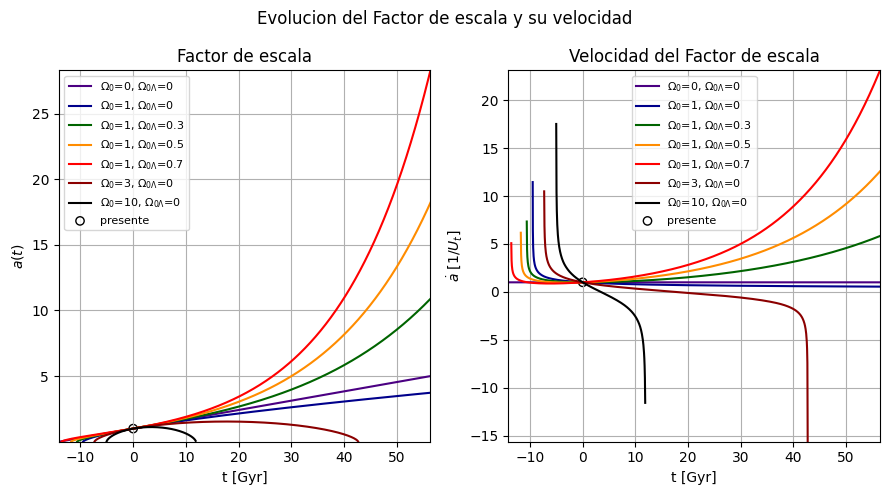

In [ ]:
# datos en formato aplanado
data_a_t = [i for par in zip(t_s, a_s) for i in par]
data_da_t= [i for par in zip(t_s, da_s) for i in par]


# configura ciclo de colores
color = ['#4B0082','#00008B','#006400','#FF8C00','r','#8B0000','k']
plt.rc('axes', prop_cycle=(cycler('color',color)))


# Grafica
fig, ax = plt.subplots(1,2,figsize=(9,5),sharex=True)
plt.suptitle('Evolucion del Factor de escala y su velocidad')
ax[0].set_title('Factor de escala')
ax[0].set_ylabel('$a (t)$')
ax[0].plot(*data_a_t)
ax[1].set_title('Velocidad del Factor de escala')
ax[1].set_ylabel('$\dot{{a}}$ $[1/U_t]$')
ax[1].plot(*data_da_t)


# config grafica
labls = [f'$Ω_0$={Ω_0[i]}, $Ω_{{0Λ}}$={Ω_0Λ[i]}' for i in range(len(Ω_0))]
for i, ax in enumerate(ax.flatten()):
    for j in range(len(Ω_0)):
      ax.plot([],[],label=labls[j])
    ax.scatter(0,1,label='presente',edgecolor='k',facecolor='none')
    ax.set_xlabel('t [Gyr]')
    ax.legend(fontsize=8)
    ax.margins(0)
    ax.grid()
plt.tight_layout()
plt.show()

La presencia de energia oscura es la causa principal de que el factor de escala tenga una expansion abierta o indefinida hacia el futuro, mientras mas energia oscura hay, la expansion será mas acelerada. El hecho de que el parametro total de densidad sea 1 (critico) tambien causa una expansion indefinida, y en los casos criticos sin energia oscura, la expansion será monotona y asintotica. Por otra parte, en universos donde la densidad total sea mayor que la critica, el parametro de escala tenderá a crecer y luego de cierto tiempo a colapsar.

#### **Evolución de $H(t)$, $\rho(t)$ y $\ddot a(t)$**

Estos campos, al presentar un comportamiento asistotico con cambio repentino, se graficaron en escala normal en la primer fila y en escala logaritmica en la segunda fila (logaritmica simetrica en los casos donde se presentan valores mixtos negativos y positivos)

* semilog fuente:
https://stackoverflow.com/questions/43372499/plot-negative-values-on-a-log-scale



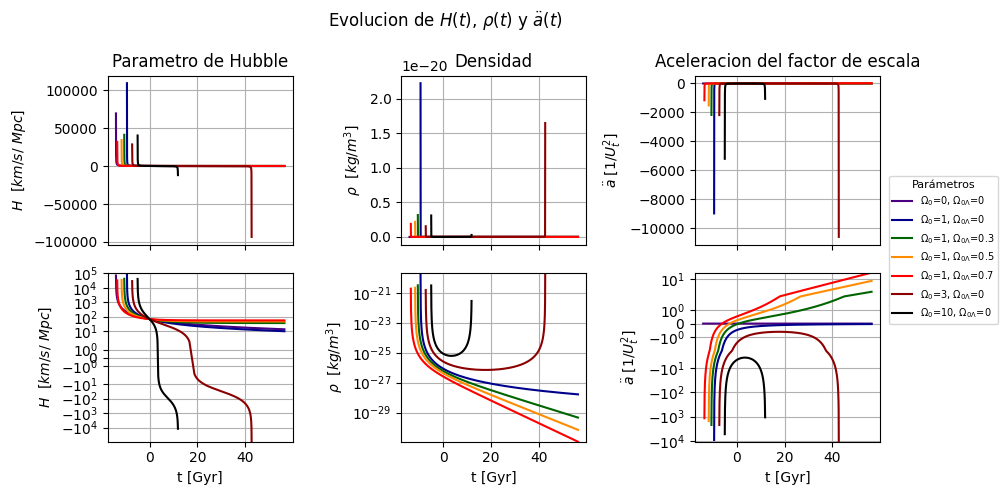

In [ ]:
# datos en formato aplanado
data_H_t = [i for par in zip(t_s, H_s) for i in par]
data_ρ_t = [i for par in zip(t_s, ρ_s) for i in par]
data_dda_t=[i for par in zip(t_s, dda_s) for i in par]


# Grafica
fig, ax = plt.subplots(2,3,figsize=(9, 5),sharex=True)
plt.suptitle('Evolucion de $H(t)$, $ρ(t)$ y $\ddot{a}(t)$')

# escala normal
ax[0,0].set_title('Parametro de Hubble')
ax[0,0].set_ylabel('$H$  $[km/s/ \ Mpc]$')
ax[0,0].plot(*data_H_t)
ax[0,1].set_title('Densidad')
ax[0,1].set_ylabel('$ρ$  $[kg/m^3]$')
ax[0,1].plot(*data_ρ_t)
ax[0,2].set_title(r'Aceleracion del factor de escala')
ax[0,2].set_ylabel('$\ddot{{a}}$ $[1/U_t^2]$')
ax[0,2].plot(*data_dda_t)

# escala logaritmica
ax[1,0].set_ylabel('$H$  $[km/s/ \ Mpc]$')
ax[1,0].set_yscale('symlog') # log simetrica
ax[1,0].plot(*data_H_t)
ax[1,1].set_ylabel('$ρ$  $[kg/m^3]$')
ax[1,1].set_yscale('log')
ax[1,1].plot(*data_ρ_t)
ax[1,2].set_ylabel('$\ddot{{a}}$ $[1/U_t^2]$')
ax[1,2].plot(*data_dda_t)
ax[1,2].set_yscale('symlog') # log simetrica

# Legend
lines=[ax[0,0].plot([],[],label=li,color=color[i])[0] \
      for i, li in enumerate(labls)]
fig.legend(handles=lines, loc='center right', bbox_to_anchor=(1.12,0.5),
           fontsize=7, title='Parámetros', title_fontsize=8)

# config grafica
for i, ax in enumerate(ax.flatten()):
    if i >= 3:
      ax.set_xlabel('t [Gyr]')
      ax.margins(0)
    ax.grid()
plt.tight_layout()
plt.show()

como se puede observar en la primera fila de la grafica, los valores de los campos tienen saltos abruptos en el inicio y al final de algunas curvas, siendo indicadores de los altos valores de cada uno que se dan al principio (big bang), y al final (big crunch: en el caso de los universos cerrados), mientras que para los universos donde se da una expansion indefinida (big rip), las curvas tienden a tener un comportamiento monotono luego del big bang.


#### **Graficacion de la velocidad en un universo cerrado**

Reciclando el mismo codigo que se usó para la animacion del universo abierto, pero esta vez tomando los datos del universo cerrado donde $Ω_0=3$ y $Ω_{0Λ}=0$ (el penultimo en la lista de los universos, luego se usa el indice -2)



In [ ]:
# campos
H_close = (H_s[-2][::10]/Ho).value
ρ_close = ρ_s[-2][::10]/U_ρ
t_close = t_s[-2][::10]

# grafica
fig, ax = plt.subplots(figsize=(6, 4))
cam = Camera(fig)
plt.title('Evolucion de la velocidad del espacio en un Universo Cerrado')
norm = Normalize(vmin=ρ_close[-1], vmax=ρ_close[0])

for i in range(len(H_close)): # cada tiempo

  # campo de densidad
  Z = np.full_like(X, ρ_close[i])
  color = cmap(norm(ρ_close[i]))
  c = ax.pcolormesh(X, Y, Z, cmap=cmap, norm=norm, alpha=0.5)

  # campo de velocidad
  vx, vy = velocity(H_close[i],rx,ry)
  ax.quiver(rx,ry,vx,vy,scale=1000)
  ax.plot(xc,yc,'k') # radio de hubble

  # label
  props = dict(boxstyle='round', facecolor='white', alpha=0.7)
  tex = f'ρ={ρ_close[i]*U_ρ:.1e} [kg/m$^3$]\n t={t_close[i]:.2f} [Gyr]'
  ax.text(0.73, 0.14, tex, transform=ax.transAxes, fontsize=9,
          verticalalignment='top', bbox=props)

  cam.snap() # captura frame

# config grafica
ax.plot([],[],'k',label='Radio de Hubble actual')
ax.legend(loc='upper right')
ax.set_xlabel('x [$U_L$]')
ax.set_ylabel('y [$U_L$]')
plt.axis('equal')
ax.set_xlim(-4,4)
ax.set_ylim(-4,4)
plt.close()

#### **Animacion de la velocidad en universo cerrado**

In [ ]:
anim = cam.animate(interval=100)  # inverval [ms] de espera por frame
HTML(anim.to_html5_video())

Como se puede observar, a diferencia del universo abierto, en este caso el campo vectorial de velocidad del espacio, cerca del big bang tiene la caracteristica de expansion con la direccion de los vectores hacia "afuera" radial positiva, mientras que al final de la simulacion, en el big crunch, la direccion de la velocidad cambia a radial negativa, lo que indica el colapso al final de este tipo de universos.
<br><br>

___

## **II. Deducciones teóricas:**

___

### **5. Loopback Time**.

   5. Hay una forma de calcular la edad del
   universo, que en los experimentos anteriores tuvo que encontrarse manualmente.  Para ello se define el que se conoce como el *loopback time* (tiempo de mirada atrás), $t_{LB}$. Este número es el tiempo que se ha expandido el universo desde un valor específico del factor de escala $a(t)$ hasta el presente cuando $a(t_0)=1$. **Mostrar** que el tiempo cósmico correspondiente a un determinado valor de $a$ se puede obtener con una integral:

Partiendo de la definición del parámetro de Hubble:
$$ H=\frac{\dot a}{a} = \frac{1}{a} \frac{da}{dt}$$

Separando variables e integrando para el tiempo desde un $a$ arbitrario hasta el presente $a_0$:
$$ dt= \frac{1}{a} \frac{da}{H(a)}$$

$$ t(a_0)-t(a) = ∫_{a}^{a_0=1} \frac{1}{a'} \frac{da'}{H(a')} $$

$$ \boxed{t_{LB}(a) = t_0 - t(a) = \int_{a}^{1} \frac{\mathrm{d}a'}{a' H(a')}}$$

donde $t_0$ es el tiempo actual. Nótese que, por definición, cuando $a=0$ el $t_{LB}$ es la edad $\tau_0$ del universo.

<br>

___

### **6. Evolución de H en funcion de densidades y factor de escala**

6. Para calcular el $t_{LB}$ es necesario encontrar una ecuación que nos de $H$ como función de $a$. Eso se logra despejando $H$ de la ecuación de Friedman-Lemeitre:

  $$ \epsilon=\frac{4 \pi}{3} G a^2\left[\frac{3 H^2}{8 \pi G}-\left(\rho_m+\rho_{\Lambda}\right)\right] $$

   donde recordemos $\epsilon$ es una constante. **Demuestre** que $H$ se puede escribir en terminos de las densidades de materia, energia oscura, y una densidad ficticia denominada *densidad de curvatura* (por un término usado en relatividad general) $ \rho_k \equiv \frac{3 \epsilon}{4\pi G} \frac{1}{a^2}$

Despejando $H$ de la ec. de Friedmann, y usando las definiciones de densidad de curvatura y densidad critica (para el caso actual) $ρ_{c0}= \frac{3 H^2_0}{8πG}$

$$ \frac{3ϵ}{4πG a^2} =  \frac{3 H^2}{8πG}-ρ_m-ρ_Λ $$
$$ \frac{3 H^2}{8πG} \frac{H^2_0}{H^2_0} = ρ_k + ρ_m + ρ_Λ $$
$$ \boxed{ \frac{H^2}{H_0^2} = \frac{ρ+ ρ_Λ + ρ_k}{ρ_{c0}}} $$

   
La idea es poner el integrando de la edad del universo en terminos de una sola variable ($a'$) para poder resolver la integral, es decir encontrar $H$ en terminos unicamente de $a$. Como ya se tiene $H$ en terminos de las densidades, y sabemos que estas dependen del factor de escala segun:

* Densidad de materia (cuadratura de ec. continuidad): $ρ_m=ρ_{0m}(a_0/a)^3$
* Densidad de energía oscura (cte en el tiempo): $ρ_Λ = ρ_{0Λ}$  
* Densidad de curvatura: $ρ_k = ρ_{0k} (a_0/a)^2$. <br>

Reemplazando estas expresiones en la ecucion anterior, se obtiene $H$ en terminos del factor de escala, y las constantes omega definidas como $Ω_i ≡ ρ_i/ρ_c$

$$  H^2 = H_0^2 \frac{ρ + ρ_Λ + ρ_k}{ ρ_{c0} }  $$

$$  H = H_0 \sqrt{ [\ ρ_{0m}(a_0/a)^3 +ρ_{0k}(a_0/a)^2 +ρ_{0Λ}\ ] / ρ_{c0}}$$

$$ \boxed{  H(a) = H_0 \sqrt{Ω_{0m}(a_0/a)^3 + Ω_{0k}(a_0/a)^2 + Ω_Λ} }$$

<br>

___

### **7. Edad del universo teórica**

7. En astrofísica, el corrimiento al rojo se relaciona con el factor de escala así: $a/a_0 = 1/(1+z)$. **Demuestre**, teniendo en cuenta la ecuación para $H(a)$ que la integral del tiempo $t_{LB}$ se puede escribir en terminos de $z$.


Aprovachando la relacion inverza entre $a$ y $z$, tal vez al hacer este cambio de variable en la integral puede de cierta forma facilitar el calculo numericamente. Como se desea hacer el cambio de variable, es util encontrar la relacion entre sus diferenciales:

$$ 1+z = a_0/ a $$
$$ dz = -a_0 da/ a^2 $$
$$ da = -a^2 dz/a_0 $$
$$ da = -[ \ a_0/(1+z) \ ]^2 dz/a_0 $$
$$ da = -a_0 dz / (1+z)^2 $$

Ademas, los limites de integracion tambien cambian:

* cuando $a=a_0=1$ (actualidad) se tiene: $ z = 1-1=0 $
* cuando $a=0$ (big bang) se tiene: $ \lim_{a \to 0}  z = \frac{a_0}{a}-1 = \lim_{z \to \infty} z $

Reemplazando lo anterior en la integral:

$$ t_{LB}(a) = ∫_a^{a_0} \frac{ da' }{ a'H(a') }$$

$$ t_{LB}(z) = ∫_z^0 \frac{ -a'_0 dz/(1+z)^2 } { [\ a'_0/(1+z)\ ] H_0 \sqrt{Ω_{0m}(1+z)^3 + Ω_{0k}(1+z)^2 + Ω_Λ}}$$

$$ t_{LB}(z) = \frac{1}{H_0} ∫_0^z \frac{dz}{(1+z)\sqrt{Ω_{0m}(1+z)^3 + Ω_{0k}(1+z)^2 + Ω_Λ}} $$

$$ \boxed{ t_{LB}(z) = t_H ∫_0^z \frac{dz}{(1+z)\sqrt{Ω_{0m}(1+z)^3 + Ω_{0k}(1+z)^2 + Ω_Λ}}} $$
<br>

Donde $t_H=1/H_0$, note que esta es la misma unidad canonica del tiempo definida en los primeros puntos. Asi pues, integrando desde ahora ($z=0$) hasta el big bang ($z → ∞ $) se obtiene la edad del universo:

$$ τ_0 = t_H ∫_0^∞ \frac{dz}{(1+z)\sqrt{Ω_{0m}(1+z)^3 + Ω_{0k}(1+z)^2 + Ω_Λ}} $$

<br><br>

**Resolviendo la integral del tiempo numericamente**

Usando la rutina `scipy.integrate.quad` para hacer esta integral (como limite superior `np.inf` y la rutina entiende que es una integral impropia) se obtuvo la edad del universo hoy con una cierta incertidumbre.

Antes, se tiene que definir el parametro Omega de curvatura; asumiendo un universo plano segun el CMB:
$$ Ω = 1 = Ω_m + Ω_k + Ω_Λ $$


In [ ]:
# parametro omega de curvatura
Ω_0k_p18 = 1 - Ω_0m_p18 - Ω_0Λ_p18
Ω_0k_p18

0.001493694455455885

Definiendo la **funcion del integrando del lookback time** a pasarle al integrador quad de scipy.integrate, y definiendo las variables faltantes como el $t_H$

In [ ]:
t_H = 1/Ho.to('1/Gyr').value # [Gyr]

# integrando del lookback time
def time_lb(z):

  """
  integrando de  loopback time para resolver
  con quad de scipy.integrate

  input:  z: redshift (variable independiente)
  output: integrando
  """
  integrando = t_H/( (1+z)*(Ω_0m_p18*(1+z)**3 + \
                            Ω_0k_p18*(1+z)**2 + \
                            Ω_0Λ_p18)**.5 )
  return integrando

# integral por quadratura
age, dt = integral(time_lb, 0,np.inf, epsrel=1e-4)

**Comparacion general de las estimaciones de la edad del universo**



In [ ]:
print(f"Edad del universo segun:\n")

print(f"- Mision WMAP9 =  {age_w9:.4f} [Gyr]")
print(f"- Lookback time τ0 =  {age:.4f} ± {dt/age*100:.2e}% [Gyr]")
print(f"- Sistema Friedmann Laimetre =  {-t_s[-3][0]:.4f} [Gyr]")
print(f"- Unidad canonica de tiempo =  {t_H:.4f} [Gyr]")
print(f"- Sistema universo fluido =  {age_try:.4f} [Gyr]")

Edad del universo segun:

- Mision WMAP9 =  13.7689 [Gyr]
- Lookback time τ0 =  13.4725 ± 4.21e-10% [Gyr]
- Sistema Friedmann Laimetre =  13.5548 [Gyr]
- Unidad canonica de tiempo =  14.1055 [Gyr]
- Sistema universo fluido =  11.1600 [Gyr]


Se evidencia que la introduccion de la energia oscura en el Friedmann-Laimetre da una mejor aproximacion al valor de la edad comparada con el sistema del universo fluido, y ademas el valor encontrado por la integracion del lookback time tambien da una buena aproximacion.

<br><br><br>

___

**Resultados esperados**:

- Este notebook con el procedimiento debidamente comentado.

- Gráficos esperados:
  - Evolución hacia el futuro y hacia el pasado de la densidad y el parámetro de Hubble para las condiciones actuales del universo (punto 2 y 3).
  - Evolución de: factor de escala, parámetro de Hubble, aceleración y densidad para cada uno de los modelos cosmológicos (punto 4).

- Datos esperados:
  - Unidades canónicas cosmológicas.
  - Edad del universo obtenida con ensayo y error en el punto 3.
  - Edad del universo para los distintos modelos cosmológicos, obtenidos por ensayo y error en el punto 4.
  - Respuestas a las preguntas del punto 5 a 6.
  - Edades del universo calculadas de forma exacta en el punto 7.

- En caso de utilizar ayudas como `ChatGPT` o códigos de `Stack Over Flow` debe citar debidamente la fuente, pero también entender a cabalidad el código, el profesor puede pedir justificación.